In [23]:
import pandas as pd
from pathlib import Path

csv_path = Path.cwd().parent / 'taba-2.xlsx'
df = pd.read_excel(csv_path)
df.head()

,Year,4 or more %
0,2024,38.7
1,2023,38.3
2,2022,37.7
3,2021,37.9
4,2020,37.5


In [24]:
import import_ipynb
from yahoo import getSP500_data

sp500 = getSP500_data()

# Convert monthly S&P 500 data into yearly totals/summaries.
sp500 = (
    sp500.assign(Year=pd.to_datetime(sp500['Date']).dt.year)
    .groupby('Year', as_index=False)
    .agg(
        First_Closing_Price=('First_Closing_Price', 'first'),
        Final_Closing_Price=('Final_Closing_Price', 'last'),
        Yearly_Increase=('Monthly_Increase', 'sum'),
        Avg_Volatility=('Volatility', 'mean')
    )
)

sp500

,Year,First_Closing_Price,Final_Closing_Price,Yearly_Increase,Avg_Volatility
0,1927,17.660000,17.660000,0.000000,NaN
1,1928,17.760000,24.350000,6.830002,0.141275
2,1929,24.809999,21.450001,-2.789999,0.303544
3,1930,21.180000,15.340000,-7.529999,0.261525
4,1931,15.850000,8.120000,-6.229999,0.383881
...,...,...,...,...,...
95,2022,4796.560059,3839.500000,-1041.879639,0.238153
96,2023,3824.139893,4769.830078,794.740234,0.126586
97,2024,4742.830078,5881.629883,1255.529297,0.122782
98,2025,5868.549805,6845.500000,1202.130371,0.156009


In [25]:
print('df columns:', list(df.columns))
# print('df dtypes:')
# print(df.dtypes)
print('\nsp500 columns:', list(sp500.columns))
# print('sp500 dtypes:')
# print(sp500.dtypes)

df columns: ['Year', '4 or more %']

sp500 columns: ['Year', 'First_Closing_Price', 'Final_Closing_Price', 'Yearly_Increase', 'Avg_Volatility']


In [26]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Merge yearly rows and sort chronologically.
merged = df.merge(sp500, on='Year', how='inner').sort_values('Year').reset_index(drop=True)

# CONFIG: choose what to predict and whether predictors are lagged.
target_col = 'First_Closing_Price'
base_feature_cols = ['4 or more %', 'Yearly_Increase', 'Avg_Volatility']
use_lagged_features = False
lag_periods = 1

# Keep only columns that exist.
base_feature_cols = [c for c in base_feature_cols if c in merged.columns]
if target_col not in merged.columns:
    raise ValueError(f"Target column '{target_col}' was not found.")
if '4 or more %' not in base_feature_cols:
    raise ValueError("'4 or more %' must be in base_feature_cols to be used as a predictor.")

# Convert selected columns to numeric (handles values like '23.4%').
for col in [target_col] + base_feature_cols:
    if merged[col].dtype == 'O':
        merged[col] = pd.to_numeric(
            merged[col].astype(str).str.replace('%', '', regex=False).str.strip(),
            errors='coerce'
        )
    else:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

model_df = merged[['Year', target_col] + base_feature_cols].copy()

feature_cols = []
if use_lagged_features:
    for col in base_feature_cols:
        lag_col = f'{col}_lag{lag_periods}'
        model_df[lag_col] = model_df[col].shift(lag_periods)
        feature_cols.append(lag_col)
else:
    feature_cols = base_feature_cols.copy()

model_df = model_df[['Year', target_col] + feature_cols].dropna().reset_index(drop=True)

if len(model_df) < 12:
    raise ValueError('Not enough rows after filtering to run a stable time-split model.')

# Time-aware split: earliest 80% train, latest 20% test.
split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df[target_col]
y_test = test_df[target_col]

models = {
    'LinearRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('reg', LinearRegression())
    ]),
    'HuberRegressor': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('reg', HuberRegressor(max_iter=2000))
    ]),
    'RandomForestRegressor': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('reg', RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42
        ))
    ])
}

results = []
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    nonzero_mask = y_test != 0
    if nonzero_mask.any():
        mape = np.mean(np.abs((y_test[nonzero_mask] - y_pred[nonzero_mask]) / y_test[nonzero_mask])) * 100
    else:
        mape = np.nan

    results.append({
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE_%': mape,
        'test_rows': len(y_test)
    })

results_df = pd.DataFrame(results).sort_values(['RMSE', 'MAE'], ascending=True).reset_index(drop=True)

print('Target:', target_col)
print('Predictors:', feature_cols)
print('Lag enabled:', use_lagged_features, '| lag periods:', lag_periods)
print('Rows used:', len(model_df), '| Train:', len(train_df), '| Test:', len(test_df))
results_df

Target: First_Closing_Price
Predictors: ['4 or more %', 'Yearly_Increase', 'Avg_Volatility']
Lag enabled: False | lag periods: 1
Rows used: 68 | Train: 54 | Test: 14


,model,MAE,RMSE,R2,MAPE_%,test_rows
0,LinearRegression,1553.215715,1894.361946,-1.699719,50.953802,14
1,RandomForestRegressor,1595.379240,1970.300991,-1.920504,50.830246,14
2,HuberRegressor,1669.729643,2005.044992,-2.024411,55.828920,14


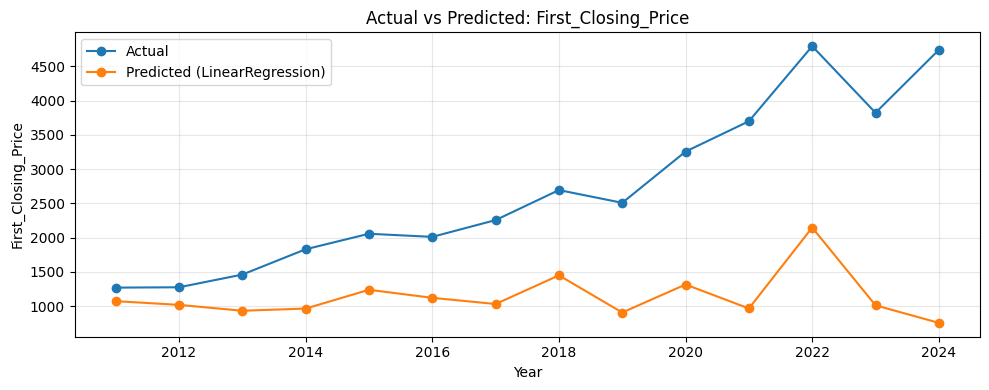

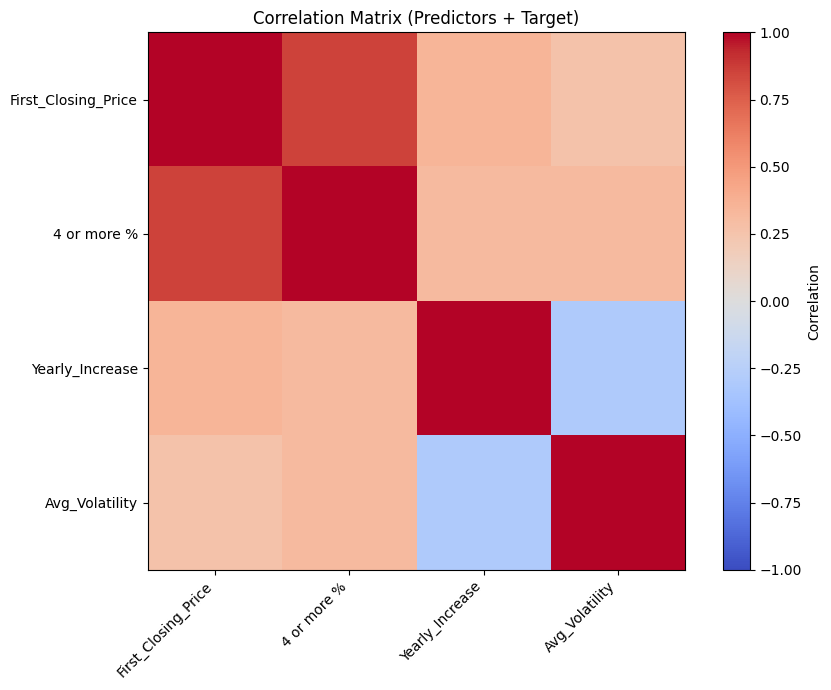

,First_Closing_Price,4 or more %,Yearly_Increase,Avg_Volatility
First_Closing_Price,1.000,0.852,0.347,0.263
4 or more %,0.852,1.000,0.320,0.319
Yearly_Increase,0.347,0.320,1.000,-0.299
Avg_Volatility,0.263,0.319,-0.299,1.000


In [27]:
import matplotlib.pyplot as plt

# Pick the best model by RMSE.
best_model_name = results_df.iloc[0]['model']
best_pred = predictions[best_model_name]

plot_df = pd.DataFrame({
    'Year': test_df['Year'].values,
    'Actual': y_test.values,
    'Predicted': best_pred
}).sort_values('Year')

# Actual vs predicted by year.
plt.figure(figsize=(10, 4))
plt.plot(plot_df['Year'], plot_df['Actual'], marker='o', label='Actual')
plt.plot(plot_df['Year'], plot_df['Predicted'], marker='o', label=f'Predicted ({best_model_name})')
plt.title(f'Actual vs Predicted: {target_col}')
plt.xlabel('Year')
plt.ylabel(target_col)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Feature correlation diagnostics on model predictors.
corr_cols = [target_col] + feature_cols
corr_matrix = model_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix (Predictors + Target)')
plt.tight_layout()
plt.show()

corr_matrix.round(3)